In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
from IPython.display import Image, display
import matplotlib.cm as cm

import tensorflow as tf

import os
import shutil
from tqdm import tqdm
from random import shuffle

import cv2
from glob import glob

from tensorflow.keras import backend as K
import random
import albumentations as A
from sklearn.model_selection import train_test_split, StratifiedKFold

from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.applications.efficientnet import *
from tensorflow.keras.utils import image_dataset_from_directory

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
image_dir = Path('/content/drive/MyDrive/SkinCancer')

In [ ]:
# Get filepaths and labels
filepaths = list(image_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
image_df = pd.concat([filepaths, labels], axis=1)

In [ ]:
image_df.shape

(3297, 2)

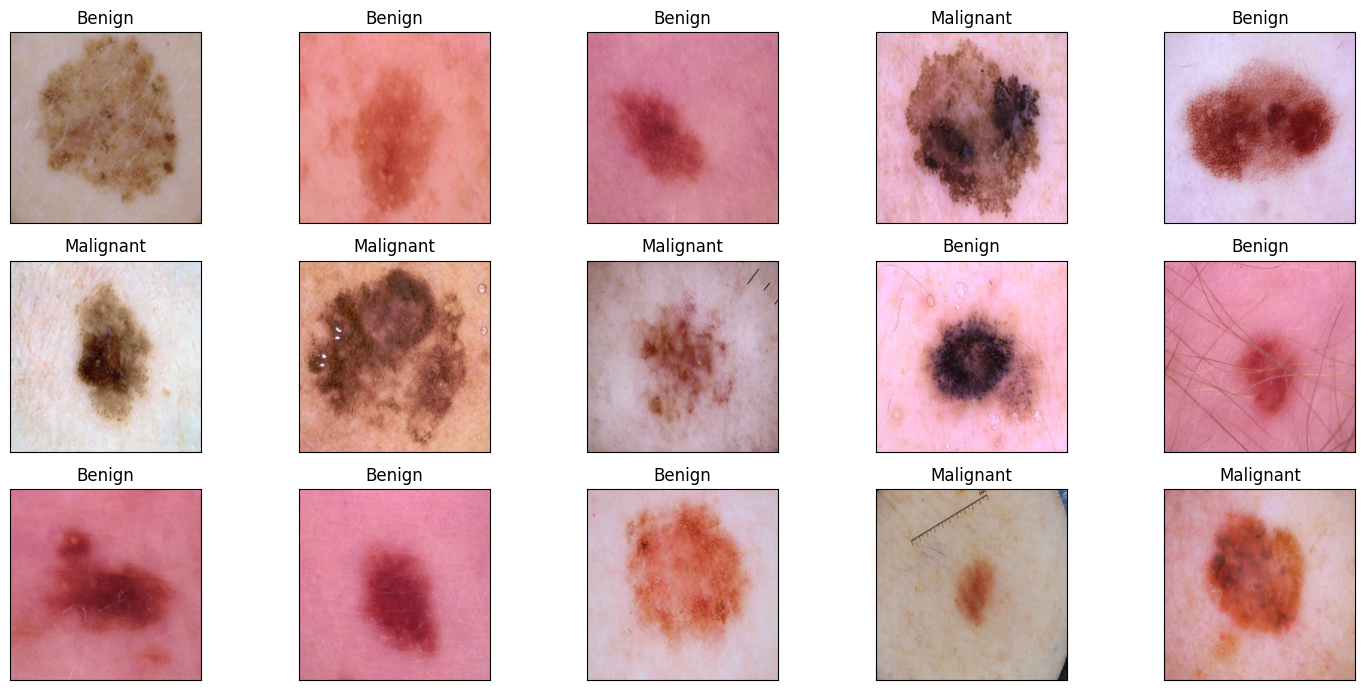

In [ ]:
# Display 20 picture of the dataset with their labels
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 7),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(image_df.Filepath[i]))
    ax.set_title(image_df.Label[i])
plt.tight_layout()
plt.show()

In [ ]:
train_df, test_df = train_test_split(image_df, train_size=0.9, shuffle=True, random_state=1)

In [ ]:
train_df.shape

(2967, 2)

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [ ]:
train_df.head(5)

,Filepath,Label
1089,/content/drive/MyDrive/SkinCancer/Malignant/10...,Malignant
2862,/content/drive/MyDrive/SkinCancer/Benign/1324.jpg,Benign
2680,/content/drive/MyDrive/SkinCancer/Benign/1731.jpg,Benign
605,/content/drive/MyDrive/SkinCancer/Benign/1155.jpg,Benign
2059,/content/drive/MyDrive/SkinCancer/Malignant/93...,Malignant


In [ ]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 2374 validated image filenames belonging to 2 classes.
Found 593 validated image filenames belonging to 2 classes.
Found 330 validated image filenames belonging to 2 classes.


In [ ]:
def create_model(input_shape=(224, 224, 3)):

    inputs = Input(input_shape)
    base_model = EfficientNetB1(input_shape=input_shape, include_top=False, classes=5)

    x = base_model(inputs)

    x = GlobalAveragePooling2D()(x)
#     x = Dropout(0.1)(x)

    x = Dense(56, activation='relu')(x)
    x = Dropout(0.1)(x)

    outputs = Dense(5, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    return model

In [ ]:
K.clear_session()

model = create_model((224, 224, 3))
# model = load_model('models/checkpoint/EfficientNetB0.h5')

metrics = [
    'accuracy',
    'AUC'
]

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=metrics)

In [ ]:
checkpoint_path = 'models/EfficientNetB1/model_224.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', mode='min', patience=15, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.1, patience=5, min_lr=0.000001, verbose=1),
    ModelCheckpoint(
        monitor='val_loss',
        mode='min',
        filepath=checkpoint_path,
        verbose=1,
        save_best_only=True,
        save_weights_only=False  # Save the entire model
    )
]


In [ ]:


# Dataset path
dataset_path = '/content/drive/MyDrive/SkinCancer'

# Load training dataset
train_dataset = image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),  # Resizing images for EfficientNet
    batch_size=32,
    validation_split=0.2,  # Use 20% for validation
    subset="training",     # Load the training subset
    seed=123               # Ensure reproducibility
)

# Load validation dataset
val_dataset = image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,  # Use the same split
    subset="validation",   # Load the validation subset
    seed=123
)

# Normalize datasets
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

# Test dataset preparation (assume `test_df` is defined)
test_generator = ImageDataGenerator(rescale=1.0 / 255)
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='sparse',  # Sparse for integer labels
    batch_size=32,
    shuffle=False
)
# Define the model
model = tf.keras.Sequential([
    tf.keras.applications.EfficientNetB1(input_shape=(224, 224, 3), include_top=False, pooling='avg'),
    tf.keras.layers.Dense(2, activation='softmax')  # 2 classes: benign and malignant
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # Use sparse categorical loss for integer labels
    metrics=['accuracy']
)

# Define callbacks
checkpoint_path = 'models/EfficientNetB1/model_224.keras'
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_best_only=True, monitor='val_loss', verbose=1)
]

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=callbacks
)


Found 3297 files belonging to 2 classes.
Using 2638 files for training.
Found 3297 files belonging to 2 classes.
Using 659 files for validation.
Found 330 validated image filenames belonging to 2 classes.
Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 877ms/step - accuracy: 0.8059 - loss: 0.4243
Epoch 1: val_loss improved from inf to 0.75926, saving model to models/EfficientNetB1/model_224.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.8061 - loss: 0.4238 - val_accuracy: 0.5508 - val_loss: 0.7593 - learning_rate: 0.0010
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.8812 - loss: 0.2564
Epoch 2: val_loss did not improve from 0.75926
83/83 ━━━━━━━━━━━━━━━━━━━━ 19s 217ms/step - accuracy: 0.8811 - loss: 0.2564 - val_accuracy: 0.5508 - val_loss: 5.5459 - learning_rate: 0.0010
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.8948 - loss: 0.2365
Epoch 3: val_loss did not improve from 0.75926
83/83 ━━━━━━━━━━━━━━━━━━━━ 23s 254ms/step - accuracy: 0.894

In [ ]:
results = model.evaluate(test_images, verbose=0)
test_accuracy = results[1] * 100

# Print results
print(f"Final Training Accuracy: {final_training_accuracy:.2f}%")
print(f"Final Validation Accuracy: {final_validation_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Final Training Accuracy: 99.85%
Final Validation Accuracy: 93.02%
Test Accuracy: 99.39%
